In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import warnings
print("all the libraries are loaded successfully")

all the libraries are loaded successfully


# Environment Setup & Library Verification



In [2]:
print(f"pandas version is {pd.__version__}")
print(f"numpy version is {np.__version__}")
print(f"seaborn version is {sns.__version__}")
print(f"sklearn version is {sklearn.__version__}")
warnings.filterwarnings('ignore')

pandas version is 2.3.1
numpy version is 2.2.6
seaborn version is 0.13.2
sklearn version is 1.8.0


# Load and Preview Dataset

In [3]:
data=pd.read_csv("StudentsPerformance.csv")

In [4]:
print(data)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [5]:
data.head(10)  # top 10 rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [7]:
data.tail(5) # last 5 rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [8]:
data.sample(8,random_state=42)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
521,female,group C,associate's degree,standard,none,91,86,84
737,female,group B,some college,free/reduced,completed,53,66,73
740,male,group D,bachelor's degree,standard,none,80,73,72
660,male,group C,some college,free/reduced,none,74,77,73
411,male,group E,some college,standard,completed,84,83,78
678,male,group D,associate's degree,free/reduced,none,81,75,78
626,male,group B,associate's degree,free/reduced,completed,69,70,63
513,female,group B,some high school,standard,completed,54,61,62


# Each row is a record while each column is the attribute and the granularity of the data is row by row

# Dataset Structure Analysis

In [9]:
data.shape # no.of rows and columns

(1000, 8)

In [10]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
data.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [12]:
data.columns.to_list()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

in this dataset i have analyzed that the datatypes are correct meaning that for text 
values the datatypes are object and for numerical type values the datatype is int
but for machine learning we have to do some categorical encoding on the columns 
to use these columns in machine learning model

# Missing Value & Duplicate Analysis

In [13]:
data.isnull().sum # check missing values

<bound method DataFrame.sum of      gender  race/ethnicity  parental level of education  lunch  \
0     False           False                        False  False   
1     False           False                        False  False   
2     False           False                        False  False   
3     False           False                        False  False   
4     False           False                        False  False   
..      ...             ...                          ...    ...   
995   False           False                        False  False   
996   False           False                        False  False   
997   False           False                        False  False   
998   False           False                        False  False   
999   False           False                        False  False   

     test preparation course  math score  reading score  writing score  
0                      False       False          False          False  
1                 

In [14]:
data.duplicated().sum() # check for duplicates

np.int64(0)

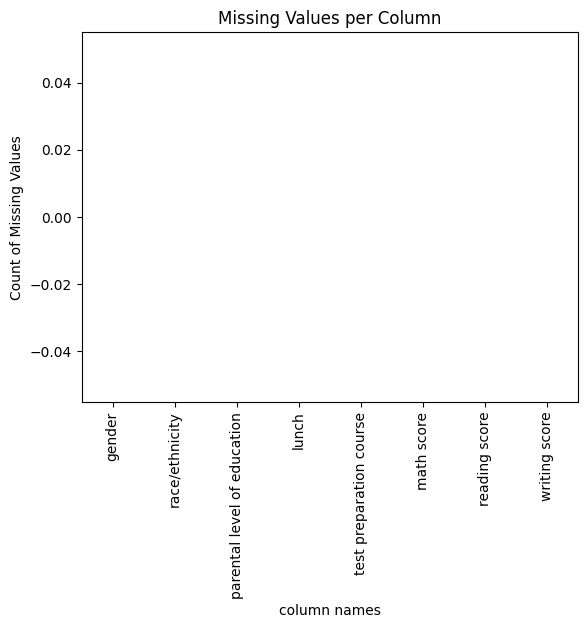

In [15]:
data,data.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("column names")
plt.ylabel("Count of Missing Values")
plt.show()


the dataset in this case is clean means there is no missing values right now 
in the dataset 
but the case if there were the missing values in the dataset i will remove them 
by either filling them with mean is there are no outliers in the dataset
fill with median if the dataset has outliers
fill with mode in the case of categorical column containing missing values 

# Descriptive Statistics Analysis

In [16]:
summary=data.describe().T.round(2)
summary.index.name = "Subject Name"




In [18]:
print(summary)

                count   mean    std   min    25%   50%   75%    max
Subject Name                                                       
math score     1000.0  66.09  15.16   0.0  57.00  66.0  77.0  100.0
reading score  1000.0  69.17  14.60  17.0  59.00  70.0  79.0  100.0
writing score  1000.0  68.05  15.20  10.0  57.75  69.0  79.0  100.0


# the highest avergae has the math Subject
# the highest variability means higher standard deviation which in this case is for writing 
# the statistics tells that the subject writing is less difficult than math but more difficult then reading

# Categorical Distribution Analysis

In [19]:
(data["gender"]).value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [20]:
(data["race/ethnicity"]).value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [21]:
(data["parental level of education"]).value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [22]:
(data["lunch"]).value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [23]:
(data["test preparation course"]).value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [24]:
data["gender"].value_counts(normalize=True)*100

gender
female    51.8
male      48.2
Name: proportion, dtype: float64

In [25]:
data["test preparation course"].value_counts(normalize=True)*100

test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64

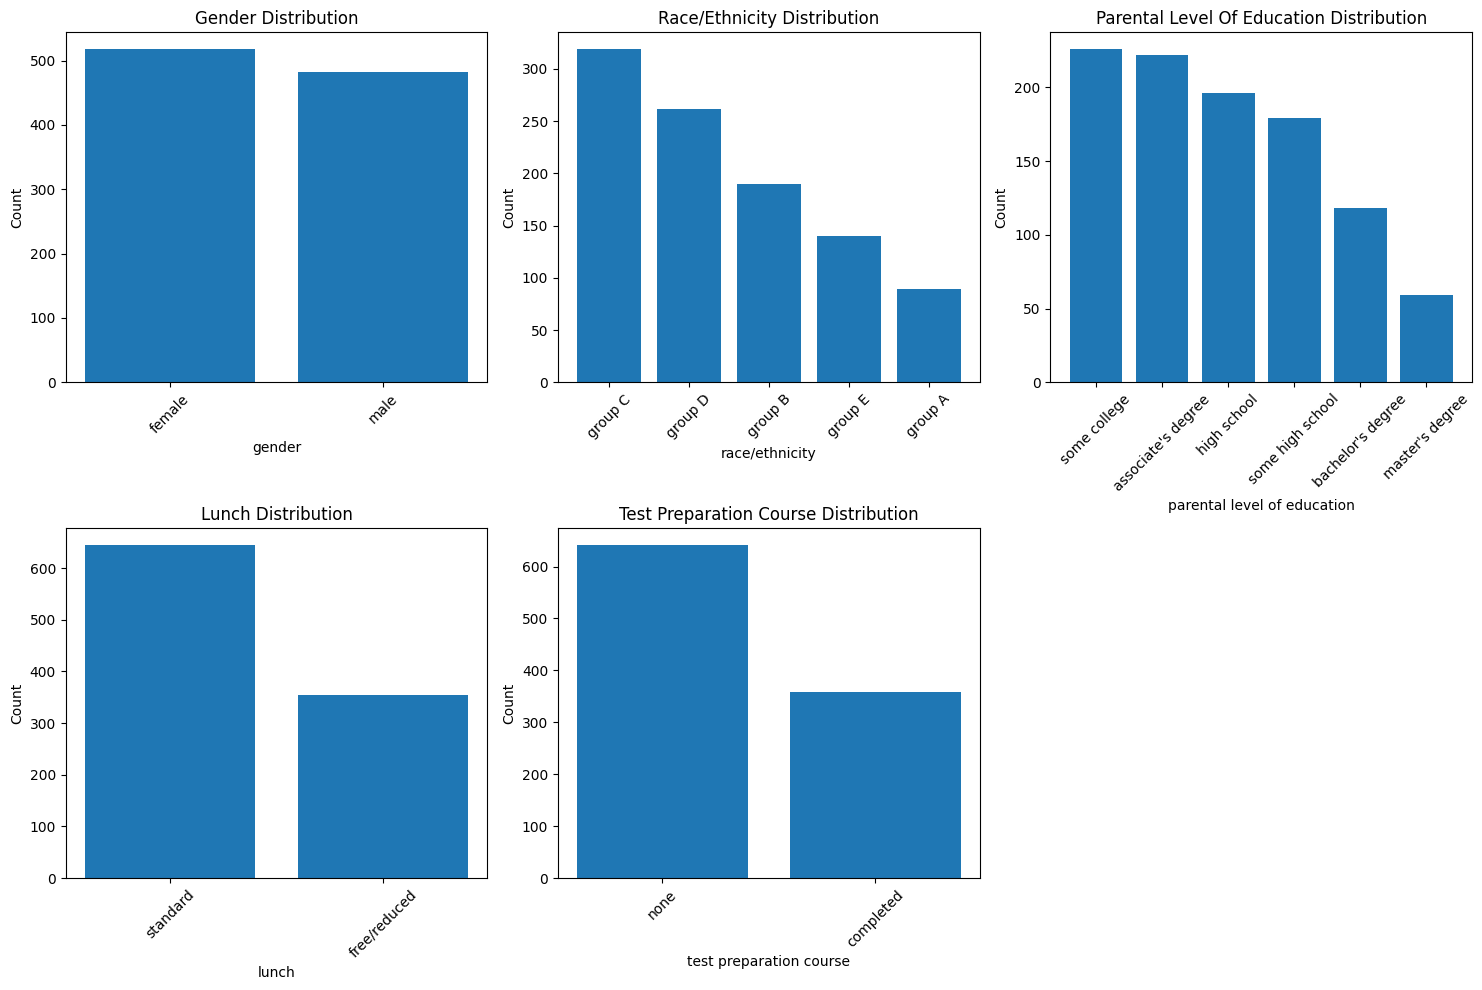

In [26]:
cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

colors = ['blue', 'green', 'red', 'purple', 'orange']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    counts = data[col].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(f'{col.title()} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# the most common parental level education is some college and the most least parental education is master degree 

# Group Mean Score Comparisons


In [27]:
score_cols = ['math score', 'reading score', 'writing score']


In [28]:
gender_scores = data.groupby('gender')[score_cols].mean().round(2)
raceethnicity_scores = data.groupby('race/ethnicity')[score_cols].mean().round(2)
parentaleducation_scores = data.groupby('parental level of education')[score_cols].mean().round(2)
lunchscores=data.groupby('lunch')[score_cols].mean()

In [30]:
gender_scores

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [31]:
raceethnicity_scores

,math score,reading score,writing score
race/ethnicity,,,
group A,61.63,64.67,62.67
group B,63.45,67.35,65.60
group C,64.46,69.10,67.83
group D,67.36,70.03,70.15
group E,73.82,73.03,71.41


In [32]:
parentaleducation_scores.sort_values(by=score_cols)

,math score,reading score,writing score
parental level of education,,,
high school,62.14,64.70,62.45
some high school,63.50,66.94,64.89
some college,67.13,69.46,68.84
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
master's degree,69.75,75.37,75.68


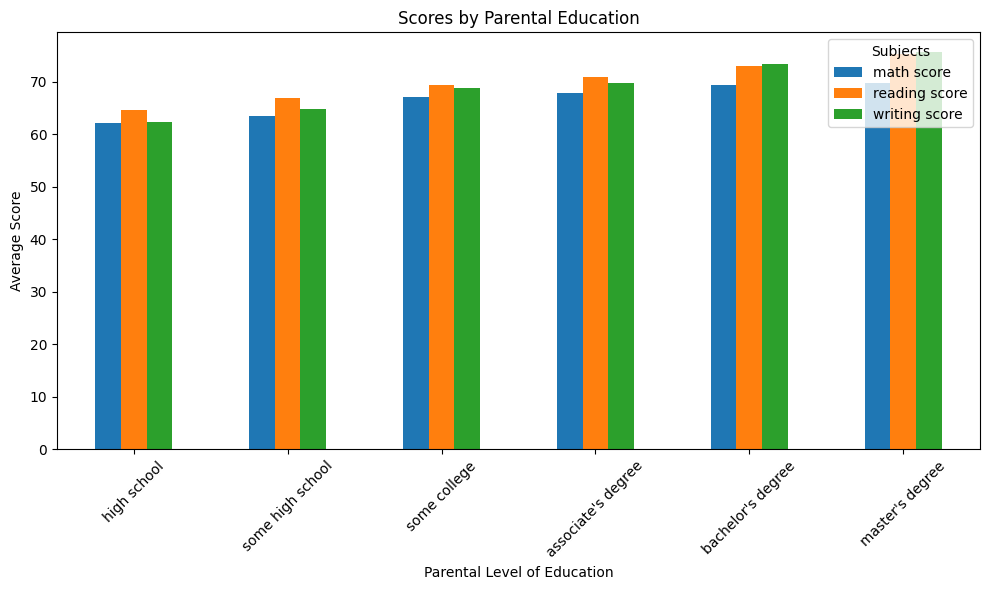

In [33]:
sorted_data = parentaleducation_scores.sort_values(by='math score')

sorted_data.plot(kind='bar', figsize=(10,6))

plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.title('Scores by Parental Education')
plt.xticks(rotation=45)
plt.legend(title='Subjects')
plt.tight_layout()
plt.show()

In [34]:
parentaleducation_scores.sort_values(by="math score")

,math score,reading score,writing score
parental level of education,,,
high school,62.14,64.70,62.45
some high school,63.50,66.94,64.89
some college,67.13,69.46,68.84
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
master's degree,69.75,75.37,75.68


# the impact of parental education is much effect has shown by stats the masters  degree parental education is dominating all others in all the three subjects

# Correlation Analysis & Heatmap


In [35]:
data[score_cols].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


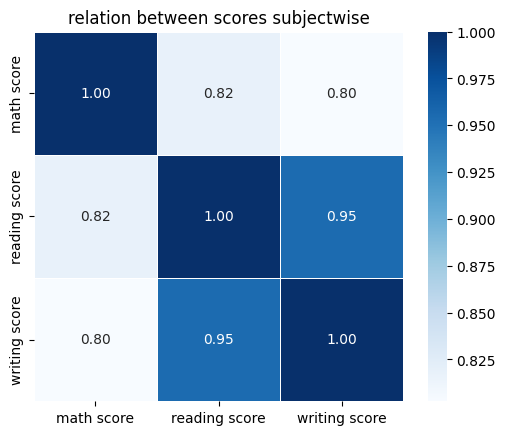

In [36]:
sns.heatmap(data[score_cols].corr(),annot=True,fmt='.2f', cmap='Blues', square=True, linewidths=0.5)
plt.title("relation between scores subjectwise")
plt.show()

In [37]:
math_reading_correlation=data["math score"].corr(data['reading score'])

In [38]:
math_reading_correlation

np.float64(0.8175796636720544)

In [39]:
writing_reading_correlation=data["writing score"].corr(data['reading score'])

In [40]:
writing_reading_correlation

np.float64(0.9545980771462478)

In [40]:
# the math_reading_correlation stats in the given analysis showing me that if 
# the person is good in math then it is not
# meant that the person is also good in writing or reading 
# the writing_reading_correlation stats in the given analysis showing me that if
# the person is good in writing then it 
# meant that the person is also good in reading and vice verca

In [42]:
score_cols = ['math score', 'reading score', 'writing score']

completed = data[data['test preparation course'] == 'completed']
none = data[data['test preparation course'] == 'none']

completed_stats = completed[score_cols].agg(['mean', 'std']).round(2)
none_stats = none[score_cols].agg(['mean', 'std']).round(2)

completed_stats, none_stats

(      math score  reading score  writing score
 mean       69.70          73.89          74.42
 std        14.44          13.64          13.38,
       math score  reading score  writing score
 mean       64.08          66.53           64.5
 std        15.19          14.46           15.0)

In [43]:
improvement = ((completed[score_cols].mean() - none[score_cols].mean()) 
               / none[score_cols].mean() * 100).round(2)

improvement

math score        8.77
reading score    11.06
writing score    15.37
dtype: float64

In [44]:
# based on the given stats i am seeing that students who have undergone the test preparation
# phase have the good scores compared to the students who dont complteted the test
# preparation phase especially in the reading and writing context 
# so the program i would refer to the students is reading and writing to be pass through 
# test preparation phase in order to achive good marks 

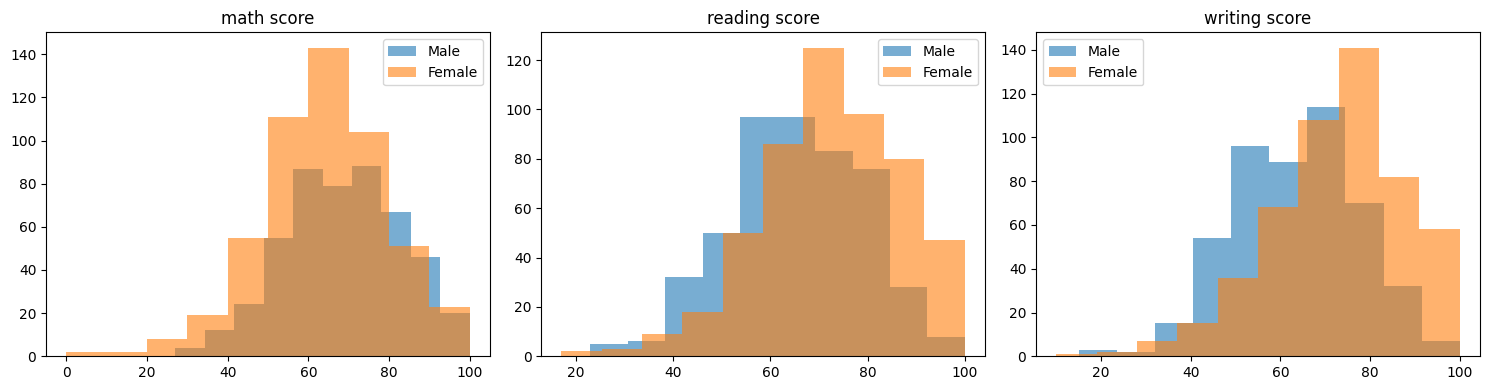

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

subjects = ['math score', 'reading score', 'writing score']

for i, subject in enumerate(subjects):
    axes[i].hist(data[data['gender']=='male'][subject], alpha=0.6, label='Male')
    axes[i].hist(data[data['gender']=='female'][subject], alpha=0.6, label='Female')
    
    axes[i].set_title(subject)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [46]:
male = data[data['gender'] == 'male']
female = data[data['gender'] == 'female']
def percent_above_70(group, subject):
    return (group[group[subject] > 70].shape[0] / group.shape[0]) * 100

results = {
    'subject': [],
    'male_%>70': [],
    'female_%>70': []
}

for subject in subjects:
    results['subject'].append(subject)
    results['male_%>70'].append(round(percent_above_70(male, subject), 2))
    results['female_%>70'].append(round(percent_above_70(female, subject), 2))

summary_df = pd.DataFrame(results)
summary_df

,subject,male_%>70,female_%>70
0,math score,45.85,32.82
1,reading score,38.38,58.30
2,writing score,32.16,58.11


In [47]:
# the females outperform the males in reading and writing
# the gaps in reading or writing b/w male and female is moderate not very large but 
# for math the male students have advantage over females
# the result may be due to some interest level between male and females the gender
# inequality is not the case

# Feature Engineering — 5 New Columns

In [48]:
data['total score']=data['math score']+data['writing score']+data['reading score']

In [55]:
data['average score']=data['total score']/3

In [56]:
def assign_grade(score):
    if score >= 80:
        return "grade A"
    elif score >= 70:
        return "grade B"
    elif score >= 60:
        return "grade C"
    elif score >= 50:
        return "grade D"
    else:
        return "grade F"

data['performance grade'] = data['average score'].apply(assign_grade)


In [57]:
def Higher_Achiver(score):
    if score >= 80:
        return True 
    else:
        return False

data['high_achiever']=data['average score'].apply(Higher_Achiver)

In [58]:
score_cols=['math score','reading score', 'writing score']

data['lowest score subject']= data[score_cols].idxmin(axis=1)


In [59]:
data['performance grade'].value_counts()

performance grade
grade B    261
grade C    256
grade A    198
grade D    182
grade F    103
Name: count, dtype: int64

In [60]:
data['lowest score subject'].value_counts()

lowest score subject
math score       552
writing score    292
reading score    156
Name: count, dtype: int64

In [61]:
score_cols = ['math score', 'reading score', 'writing score']

data['average_score'] = data[score_cols].mean(axis=1)

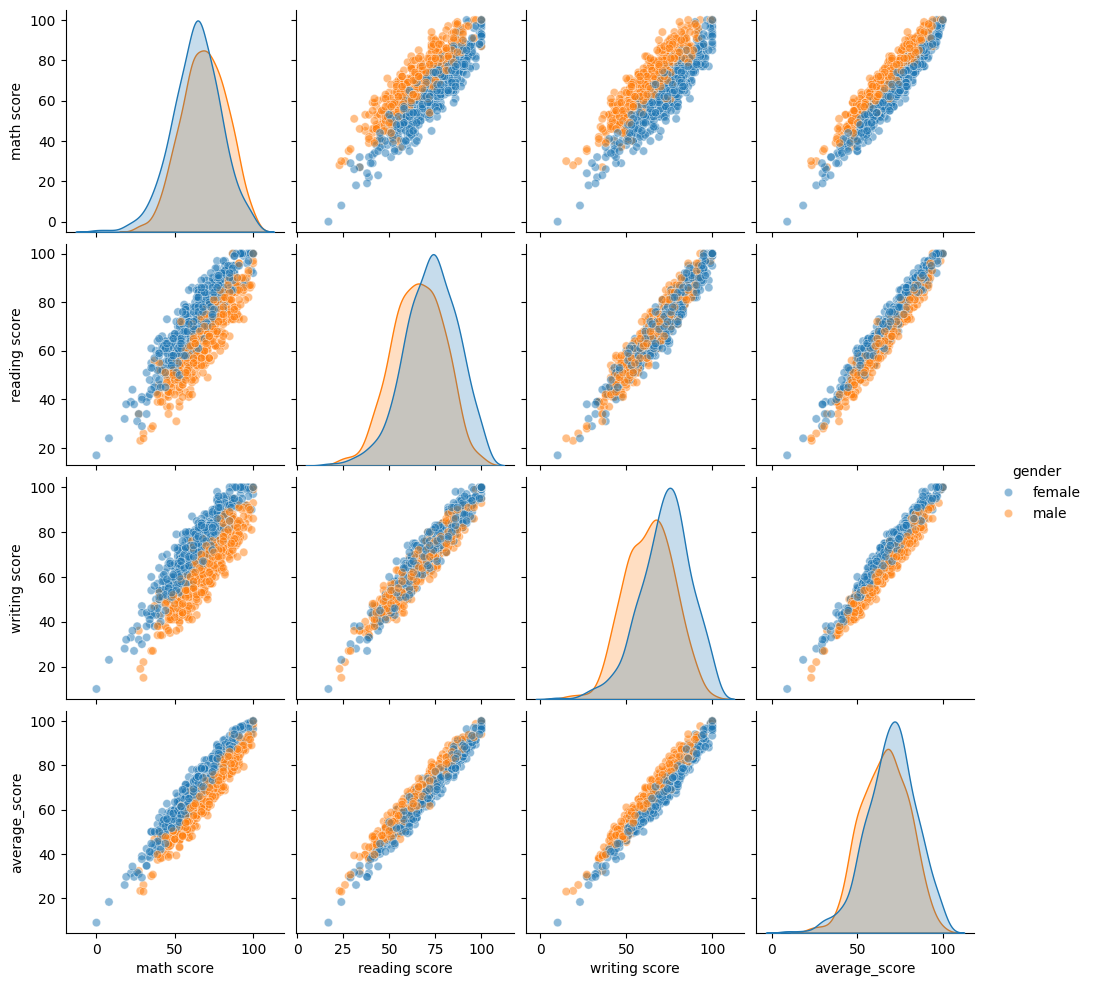

In [62]:
import matplotlib.pyplot as plt

sns.pairplot(
    data[score_cols + ['average_score', 'gender']],
    hue='gender',
    plot_kws={'alpha': 0.5}
)

plt.savefig('pairplot_scores.png', dpi=150, bbox_inches='tight')
plt.show()

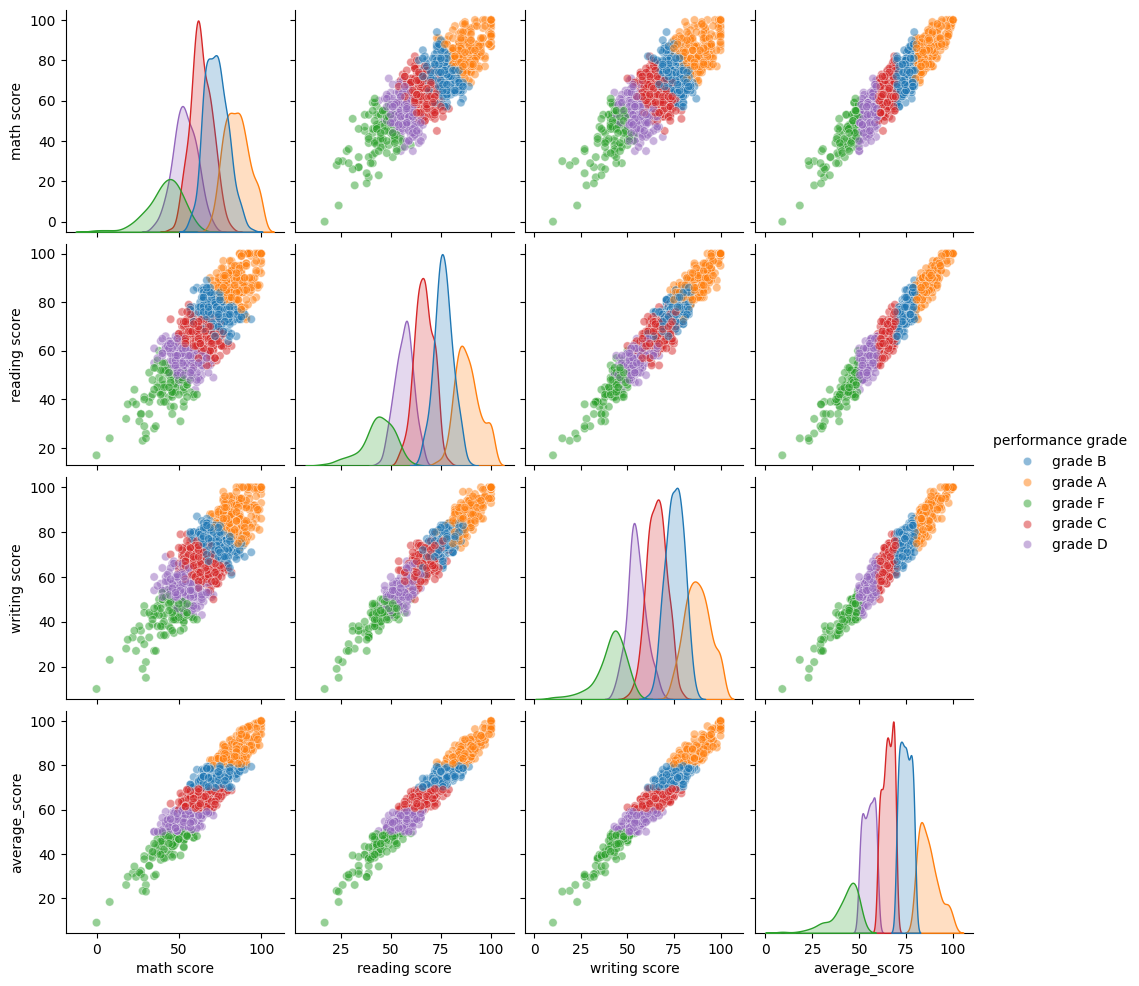

In [63]:
sns.pairplot(
    data[score_cols + ['average_score', 'performance grade']],
    hue='performance grade',
    plot_kws={'alpha': 0.5}
)
plt.savefig("pairplot_grades.png",dpi=150, bbox_inches='tight')

In [64]:
# The pair plot shows heavy overlap between classes, indicating weak separability
# therefore  only moderately complex models would achieve limited predictive accuracy 
# as gender is indirectly reflected rather than explicitly encoded in the features

In [65]:
studentpivottableanalysis=pd.pivot_table(
    data=data,
    index='parental level of education',
    columns='gender',
    values='average score'
)

In [66]:
studentpivottableanalysis.round(2)

gender,female,male
parental level of education,,
associate's degree,71.12,67.87
bachelor's degree,74.67,68.78
high school,64.75,61.58
master's degree,73.65,73.52
some college,71.00,65.72
some high school,65.56,64.64


<Axes: xlabel='gender', ylabel='parental level of education'>

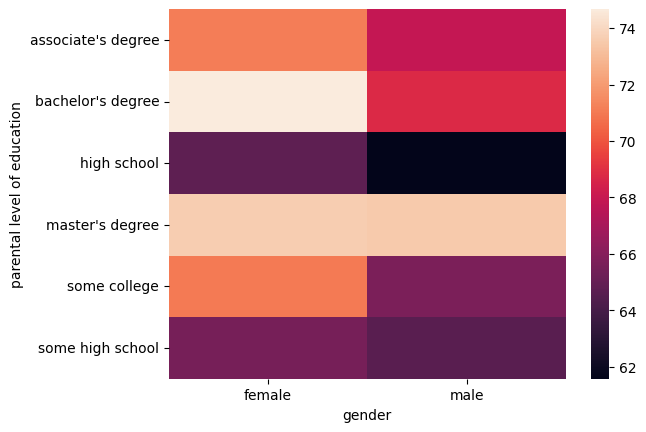

In [67]:
sns.heatmap(studentpivottableanalysis)

In [68]:


racewiseAnalysis=pd.pivot_table(
    data=data,
    index='race/ethnicity',
    columns='test preparation course',
    values='math score',
    aggfunc='mean'
   
)


In [69]:
racewiseAnalysis.round(2)

test preparation course,completed,none
race/ethnicity,,
group A,68.26,58.09
group B,67.19,61.37
group C,67.50,62.71
group D,69.79,66.26
group E,77.43,71.11


<Axes: xlabel='test preparation course', ylabel='race/ethnicity'>

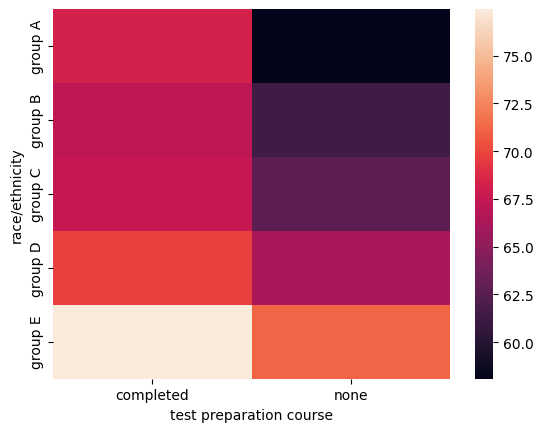

In [70]:
sns.heatmap(racewiseAnalysis)

In [71]:
# this analysis shows me that parental level of education itself has the strong effect
# on indiviual subjects scores but when i go deeper in this and want to check it on the 
# basis of gender wise parental level of education scores comparison there is no significant
# gap in most cases but in one case where parental level of education is high school
# gender male has lowest score as compared to the females


In [72]:
def data_summary_column(data,col):
    
     return {
        "mean": data[col].mean(),
        "median": data[col].median(),
        "std": data[col].std(),
        "min": data[col].min(),
        "max": data[col].max(),
        "pct_above_70": (data[data[col] > 70].shape[0] / data.shape[0]) * 100
    }
    
     

In [73]:
result=data_summary_column(data,'math score')
print(result)

{'mean': np.float64(66.089), 'median': np.float64(66.0), 'std': np.float64(15.16308009600945), 'min': np.int64(0), 'max': np.int64(100), 'pct_above_70': 39.1}


In [74]:


def plot_distribution(data, col, color):
    """
    Plots histogram with KDE and mean line.

    Parameters:
    df (DataFrame): dataset
    col (str): numeric column
    color (str): plot color
    """
    mean_val = data[col].mean()

    plt.figure(figsize=(7,4))
    sns.histplot(data[col], kde=True, color=color)

    plt.axvline(mean_val, color='black', linestyle='--', label=f"Mean: {mean_val:.2f}")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

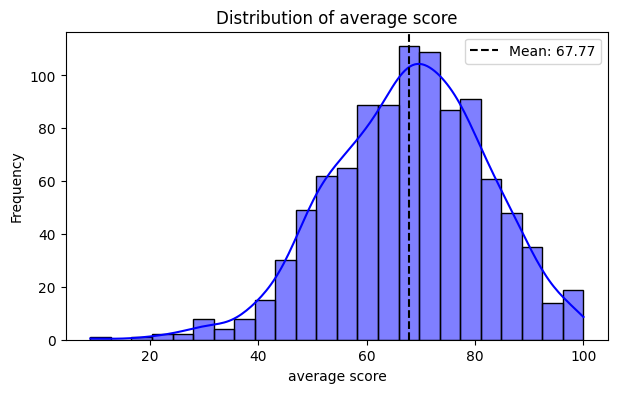

In [75]:
plot_distribution(data,'average score',"blue")

In [76]:
def compare_groups(data, group_col, score_col):
    """
    Returns group-wise mean and % scoring above 70.

    Parameters:
    df (DataFrame): dataset
    group_col (str): categorical grouping column
    score_col (str): numeric score column

    Returns:
    DataFrame: sorted by mean score (descending)
    """
    grouped = data.groupby(group_col)[score_col].agg(['mean']).reset_index()

    pct = data.groupby(group_col).apply(
        lambda x: (x[score_col] > 70).mean() * 100
    ).reset_index(name='pct_above_70')

    result = pd.merge(grouped, pct, on=group_col)
    return result.sort_values(by='mean', ascending=False).round(2)

In [77]:
compare_groups(data,'gender','math score')

,gender,mean,pct_above_70
1,male,68.73,45.85
0,female,63.63,32.82


In [78]:
compare_groups(data,'gender','reading score')

,gender,mean,pct_above_70
0,female,72.61,58.30
1,male,65.47,38.38


In [79]:
import numpy as np
mathscorearray=data['math score'].values
readscorearray=data['reading score'].values
writingscorearray=data['writing score'].values

In [80]:
def stats(col):
    return{
        "mean":col.mean(),
        "std":col.std(),
        "var":col.var(),
        "min":col.min(),
        "max":col.max(),
    }

In [81]:
stats(mathscorearray)

{'mean': np.float64(66.089),
 'std': np.float64(15.155496659628149),
 'var': np.float64(229.68907899999996),
 'min': np.int64(0),
 'max': np.int64(100)}

In [82]:
def z_outliers(arr):
    z = (arr - np.mean(arr)) / np.std(arr)
    return np.sum((z > 2) | (z < -2))

math_out = z_outliers(mathscorearray)
reading_out = z_outliers(readscorearray)
writing_out = z_outliers(writingscorearray)

math_out, reading_out, writing_out

(np.int64(46), np.int64(46), np.int64(42))

In [83]:
percentiles = [10, 25, 50, 75, 90]

math_p = np.percentile(mathscorearray, percentiles)
reading_p = np.percentile(readscorearray, percentiles)
writing_p = np.percentile(writingscorearray, percentiles)

result_table = np.array([math_p, reading_p, writing_p])
result_table

array([[47.  , 57.  , 66.  , 77.  , 86.  ],
       [51.  , 59.  , 70.  , 79.  , 87.1 ],
       [48.  , 57.75, 69.  , 79.  , 87.  ]])

In [84]:
top10_idx = np.argsort(mathscorearray)[-10:][::-1]

In [85]:
math_pass = (mathscorearray > 70).astype(int)
reading_pass = (readscorearray > 70).astype(int)
writing_pass = (writingscorearray > 70).astype(int)

math_pass_rate = np.mean(math_pass) * 100
reading_pass_rate = np.mean(reading_pass) * 100
writing_pass_rate = np.mean(writing_pass) * 100

math_pass_rate, reading_pass_rate, writing_pass_rate

(np.float64(39.1), np.float64(48.699999999999996), np.float64(45.6))

In [88]:
# # Statistical Summary
# <!-- Reading has the highest mean performance -->
# <!-- Math has the lowest mean but similar variability to writing -->
# <!-- Writing shows slightly higher spread in performance -->

In [89]:
# # Pass Rates
# <!-- Reading shows the highest pass rate (>70 threshold) -->
# <!-- Math shows the lowest pass rate -->
# <!-- Writing sits in between -->

# Professional 6-Chart EDA Dashboard

In [125]:
score_cols = ['math score', 'reading score', 'writing score']

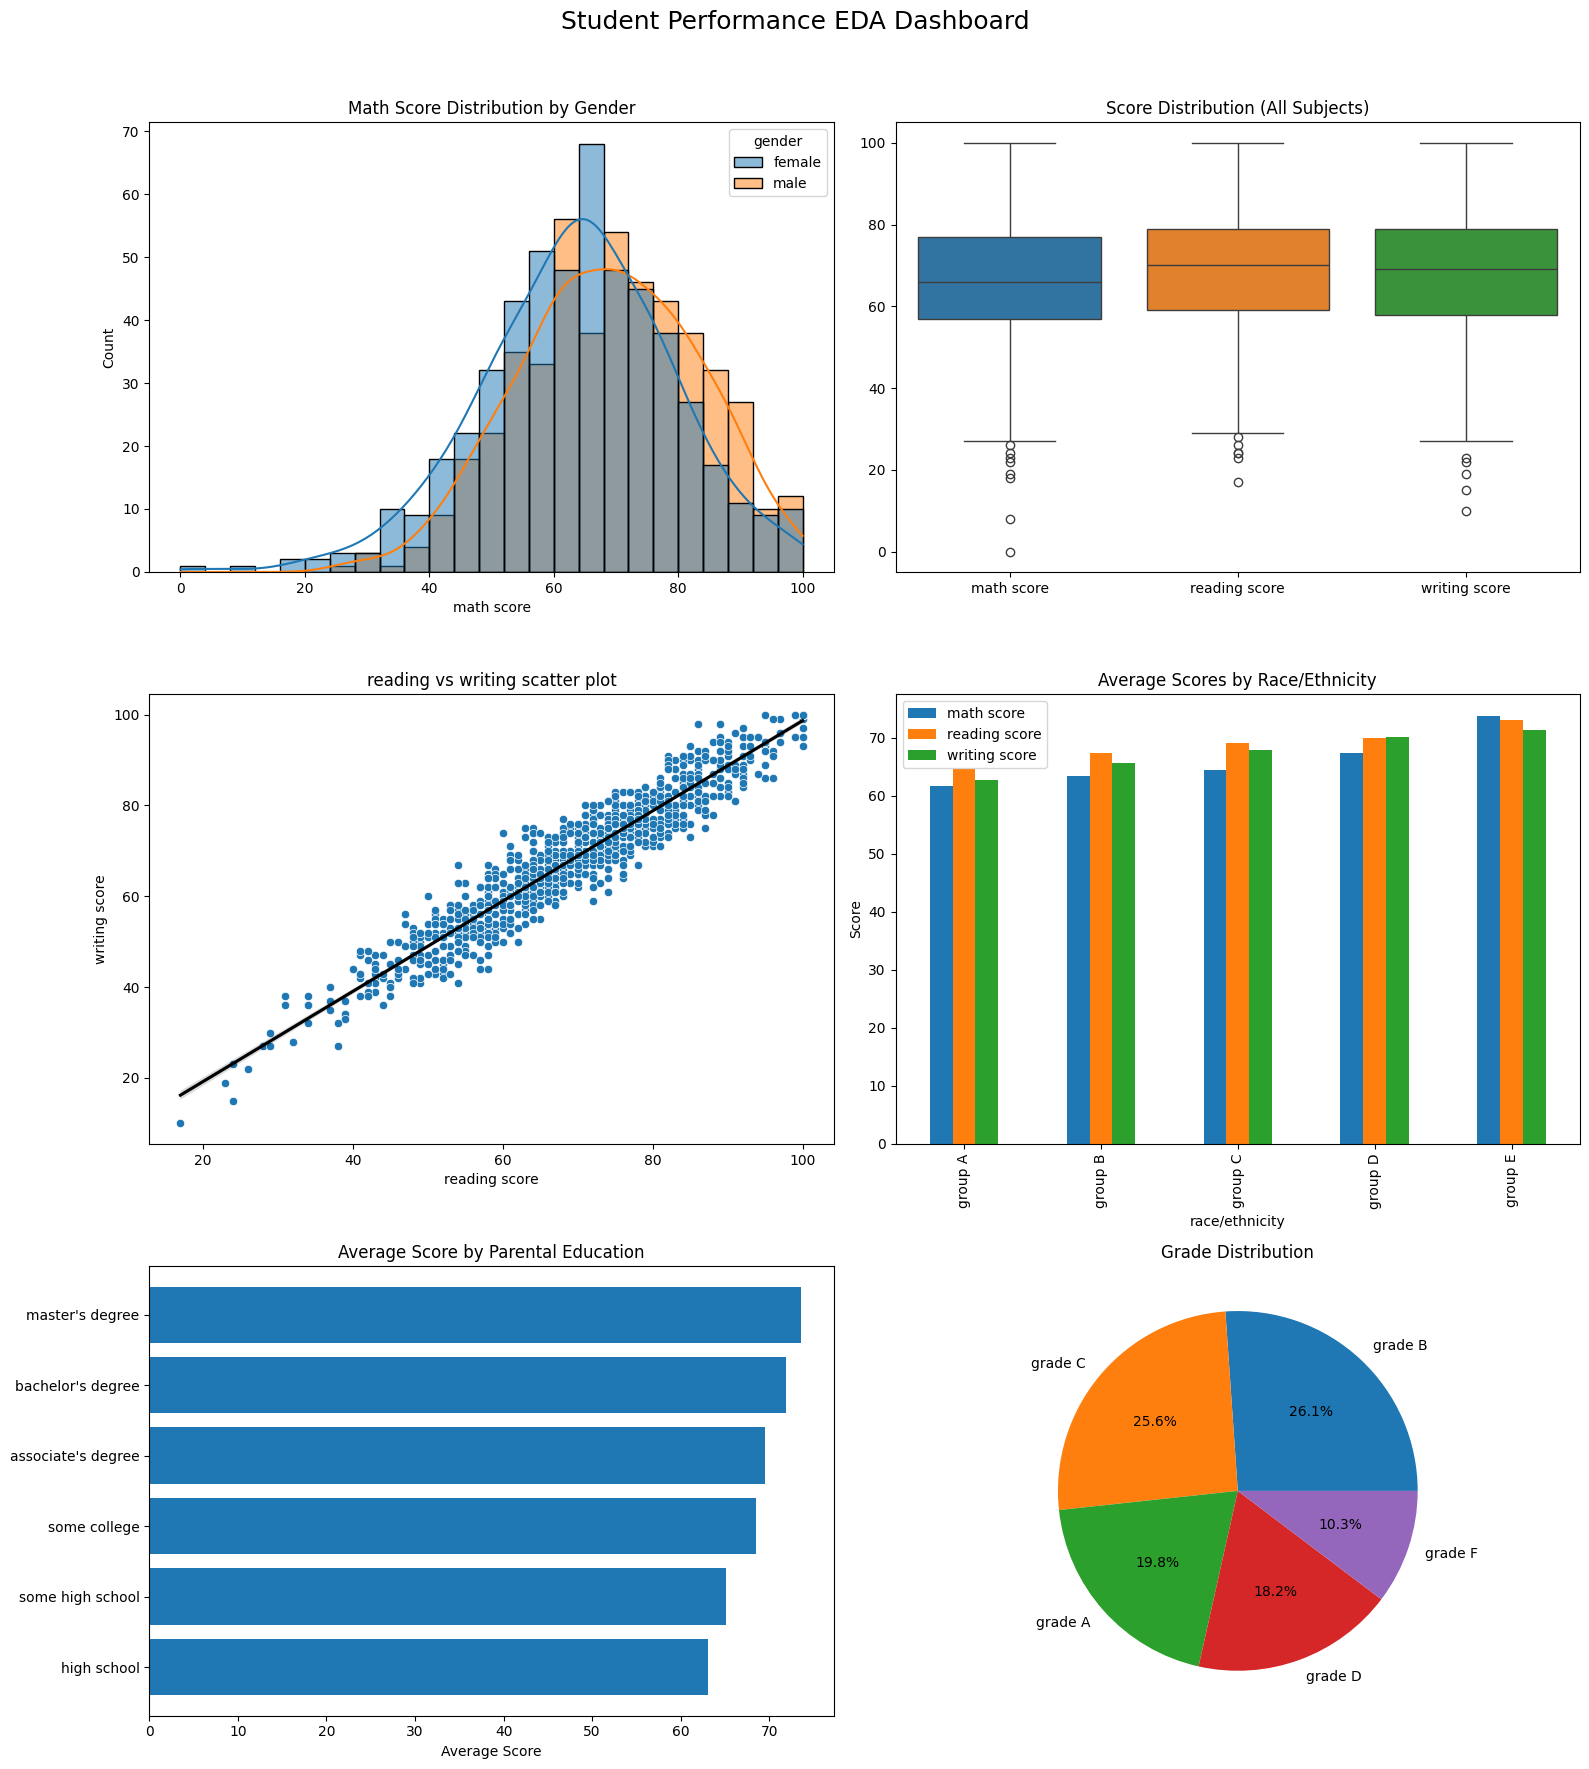

In [127]:
fig,axes=plt.subplots(3,2,figsize=(16,18))
# (1) Math histogram + KDE by gender
# -------------------------------
sns.histplot(data=data, x='math score', hue='gender', kde=True, ax=axes[0,0])
axes[0,0].set_title('Math Score Distribution by Gender')

# -------------------------------
# (2) Box plot (3 subjects)
# -------------------------------
sns.boxplot(data=data[score_cols], ax=axes[0,1])
axes[0,1].set_title('Score Distribution (All Subjects)')


# -------------------------------
# (2) Scatter plot (reading vs writing)
# -------------------------------

sns.scatterplot(data=data,x='reading score',y='writing score',ax=axes[1,0])

sns.regplot(data=data,x='reading score',y='writing score',ax=axes[1,0],scatter=False,color='black')


axes[1,0].set_title("reading vs writing scatter plot")


raceethnicitymeans=data.groupby('race/ethnicity')[score_cols].mean()
raceethnicitymeans.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Average Scores by Race/Ethnicity')
axes[1,1].set_ylabel('Score')



edu_means = data.groupby('parental level of education')['average score'].mean().sort_values()

axes[2,0].barh(edu_means.index, edu_means.values)
axes[2,0].set_title('Average Score by Parental Education')
axes[2,0].set_xlabel('Average Score')

grade_counts = data['performance grade'].value_counts()

axes[2,1].pie(grade_counts.values, labels=grade_counts.index, autopct='%1.1f%%')
axes[2,1].set_title('Grade Distribution')


plt.suptitle('Student Performance EDA Dashboard', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('eda_dashboard.png', dpi=300)

plt.show()


# Written Analysis Report 

1. Executive Summary

the dataset is of the student performance in exams and the main subjects that we want to focus on this dataset are math ,reading and writing score. i have analyzed that students performs well in reading and writing while many students especially females suffer most in math subject. i have also analyzed that test preparation have the significant imapact on the students performance as compared to the other factors like gender, parental education and lunch.

if i have to give my personal reccomendations i would reccomend that the teachers focus more on the math subject and test preparations makes mandatory for all the students so that the students perform well next time.


2. Data Quality Assessment

the dataset used to make this report is student performance dataset the dataset is cleaned and well structured to make any best report.there is not any null value in the dataset as well as there is no duplicated values in the dataset and the datatypes of the columns are shown below 

gender                          object
race/ethnicity                  object
parental level of education     object
lunch                           object
test preparation course         object
math score                       int64
reading score                    int64
writing score                    int64
total score                      int64
average score                  float64
performance grade               object
high_achiever                     bool
lowest score subject            object
average_score                  float64


3. Key Statistical Findings

the dataset has many things to focus on while exploring the dataset but the major keyfindings from this dataset are 

1:males have highest scores in math while females have highest scores in reading and writing
2:parental level of education has also impact on the student performance the masters degree parental level of education has the highes scores in all the three subjects
3:group E has most scores in all the three subjects
4:most students have grade B while some of them have grade A also
5:test preparation has stronger impact on students scores

Reading has the highest average score (~69.17)
writing has the medium average score (~68.05)
math has the lowest average score (~66.09)

Correlation analysis highlights a very strong relationship between reading and writing (~0.95), indicating these skills are closely linked.

4. Visualization Insights

The visualizations show patterns in how students do in school. The graphs of reading and writing scores are a little higher than the math scores. They look pretty smooth. The box plots show that math scores can be over the place with some really low scores but all the subjects have similar high scores. When we look at the reading and writing scores together we see that they are closely related so students who do well in reading usually do well in writing. The bar charts show that students from backgrounds and with different levels of parental education do differently in school and students with more educated parents usually do better. The chart that shows the grades of the students has a lot of students in the range with not as many really high or really low grades.

5. Feature Engineering

Feature Engineering is the technique to make new columns based on the given dataset which helps us to make important columns that we give the model for training.
We used feature engineering to make the data easier to understand and to get insights from the scores. We made a feature that shows the overall score of each student so it is easier to compare them. We also made a feature that shows the letter grade of each student so it is easier to see how they are doing. These new features help us summarize how well the students are doing and group them in a way that makes sense. We can also look at the data in groups like boys and girls or students with different levels of parental education. These new features make it easier to see patterns in the data and to understand what is going on.

6. Recommendations for educators

Educators should focus on making the math scores because they are usually lower than the reading and writing scores. They can use programs to help the students who are struggling in math. They should also help students get ready for the tests because that seems to make a difference especially in writing. Since reading and writing are closely related educators can help students with their reading skills. That will also help their writing. Some students may need help because of their background so educators should be aware of that and try to help them. If educators can tailor their teaching to the needs of each group of students that can make a difference in how well the students do.

7. What We Learned

This project shows us that it is really important to use statistics and visualizations to understand the data about education. One thing we learned is that when we look at how different thingsre related, like reading and writing we can see deeper connections that we would not have seen otherwise. We also saw that things like education and socioeconomic status have a big impact on how well students do in school. We learned that feature engineering can make complex data easier to understand. Overall this project shows us that looking closely at the data is really important if we want to make decisions, about education.
